# SEM-PGS Cascade: does the model match a simulation?

I built Cascade versions of the univariate SEM-PGS OpenMx scripts, in which spouses assort on a latent mating
phenotype γ̃ instead of on the phenotype itself (`SEM_PGS_Cascade_model.pdf`). This notebook is where I check
them. I ask four questions, in this order:

1. **Did I code the models correctly?** I fit every script to data generated from its own algebra, where the
   right answer is known exactly.
2. **Does GeneEvolve reach the state the math describes?** I simulate populations that assort on γ̃ and follow
   them generation by generation.
3. **Does the simulation agree with the iterative math?** I compare every covariance the scripts use with the
   value the math predicts.
4. **Are the OpenMx estimates unbiased on simulated data?** I fit all 20 scripts to the GeneEvolve trios and
   compare each estimate with the math.

Section 5 digs into the one pattern that stood out, some fits under social homogamy. Section 6 checks the
DisEq corrections I carried over to the original (non-Cascade) scripts.

**Setup.**
* γ̃ = AM_G·[δ(T+NT) + a(LT+LNT)] + AM_E·(F + E), and spouses' γ̃ correlate at `am` = 0.4.
* I test three mechanisms: *primary* AM (AM_G = AM_E = 1, so γ̃ = Y), *genetic homogamy* (AM_E = 0) and *social
  homogamy* (AM_G = 0).
* I test two regimes: *Eq* (assortment every generation until equilibrium) and *DisEq* (random mating with vertical
  transmission until equilibrium, then one generation of assortment).
* Each condition has 20 fitting scripts: 5 designs × Eq/DisEq × continuous/binary.
* Parameters are scaled so the parents' VY = 1, which lets the continuous and binary models share the same
  populations.
* The DiffTrait designs use a second trait for the offspring. It loads on the same PGS and latent score, receives
  the same F, and has variance 1.

**How the models are fit.**
* One mating multiplier has to be fixed to set γ̃'s scale. I fix AM_E = 1 and estimate AM_G, or under genetic
  homogamy fix AM_G = 1 and estimate AM_E.
* In the latent-parent designs I fix both multipliers at the true mechanism, because the data can't identify it.
* Continuous fits use `mxTryHard(extraTries = 30, exhaustive = TRUE)`. Binary fits use the scripts' default search,
  because each attempt takes minutes.

A few conventions used throughout:
* **θ.** θT and θNT are covariances of Yo with *one* parental haplotype (one data column). In the papers θ is the
  sum over the father's and mother's haplotypes, so it is twice these.
* **z** = (estimate − truth) / SE. For fitted parameters the SE is the one OpenMx reports; for simulated moments
  it is the SE across populations.
* **Colors** are the same everywhere: blue = primary AM, orange = genetic homogamy, green = social homogamy.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 500); pd.set_option("display.max_columns", 40)

OUT = "output"
PLOTS = os.path.join(OUT, "plots"); os.makedirs(PLOTS, exist_ok=True)
MECHS = ["primary", "genetic", "social"]
REGIMES = ["Eq", "DisEq"]
MECH_LABEL = {"primary": "Primary AM", "genetic": "Genetic homogamy", "social": "Social homogamy"}
MECH_COLOR = {"primary": "#2a78d6", "genetic": "#eb6834", "social": "#1baf7a"}
DESIGNS = ["SameTrait_ObservedYPYM", "SameTrait_LatentYPYM", "DiffTrait_LatentYPYM",
           "DiffTrait_ObservedYPYM_EstimatedAParent", "DiffTrait_ObservedYPYM_FixedAParent"]
SHORT = {"SameTrait_ObservedYPYM": "SameTrait_Obs", "SameTrait_LatentYPYM": "SameTrait_Latent",
         "DiffTrait_LatentYPYM": "DiffTrait_Latent", "DiffTrait_ObservedYPYM_EstimatedAParent": "DiffTrait_Obs_EstA",
         "DiffTrait_ObservedYPYM_FixedAParent": "DiffTrait_Obs_FixedA"}
mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#999999",
    "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 10, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 9,
    "lines.linewidth": 2,
})

gen_params = pd.read_csv(f"{OUT}/truth/generating_params.csv")
math       = pd.read_csv(f"{OUT}/truth/iterative_math.csv")
math_traj  = pd.read_csv(f"{OUT}/truth/iterative_trajectory.csv")
sim_final  = pd.read_csv(f"{OUT}/sim/moments_final.csv")
sim_traj   = pd.read_csv(f"{OUT}/sim/trajectory.csv")
rep_info   = pd.read_csv(f"{OUT}/sim/rep_info.csv")
est_mvn    = pd.read_csv(f"{OUT}/results/estimates_mvn.csv")
est_sim    = pd.read_csv(f"{OUT}/results/estimates_sim.csv")
perpop     = pd.read_csv(f"{OUT}/results/estimates_perpop.csv")
profile    = pd.read_csv(f"{OUT}/results/profile_mu.csv")
M = math.set_index(["regime", "mechanism", "quantity"])["value"]

def free_params(est):
    # structural free parameters with a known truth (the freely estimated means are nuisance parameters)
    d = est[est["true"].notna() & ~est["parameter"].fillna("").str.startswith("mean")].copy()
    d["err"] = d["estimate"] - d["true"]
    d["z"] = d["err"] / d["SE"]
    d["rel_pct"] = 100 * d["err"] / d["true"].where(d["true"].abs() > .01)
    return d

def by_model(d):
    return d.groupby(["regime", "trait", "design", "mechanism"]).apply(lambda x: pd.Series({
        "status": x["statusCode"].iloc[0], "n_free": len(x),
        "max_abs_err": x["err"].abs().max(), "max_abs_z": x["z"].abs().max(),
        "worst_param": x.loc[x["z"].abs().idxmax(), "parameter"] if x["z"].notna().any() else x.loc[x["err"].abs().idxmax(), "parameter"],
        "n_abs_z_gt3": int((x["z"].abs() > 3).sum())}), include_groups=False).reset_index()

def grid(s, value, fmt="{:.2f}"):
    # model x condition grid: rows = trait x design, columns = regime x mechanism
    g = s.pivot_table(index=["trait", "design"], columns=["regime", "mechanism"], values=value, aggfunc="first")
    g = g.reindex(columns=pd.MultiIndex.from_product([REGIMES, MECHS]))
    g.index = pd.MultiIndex.from_tuples([(t, SHORT[d]) for t, d in g.index])
    return g

## The conditions

The first table lists the generating values. They are rescaled from δ² = .2, a² = .3, VE = .5, f = .15 so that the
parents' VY is exactly 1 in each regime × mechanism.

The second table counts what I simulated:
* Eq: 12 populations of 10,000 per mechanism.
* DisEq: 36 populations, because all three mechanisms branch from the same random-mating history, so I wanted
  more of them.

I keep one offspring per family and pool the trios across populations.

In [2]:
gen_params.set_index(["regime", "mechanism"])[["delta", "a", "VE", "f", "am", "AM_G", "AM_E", "delta_o", "a_o", "VE_o"]].round(4)

delta       a      VE     f   am  AM_G  AM_E  delta_o   a_o    VE_o
regime mechanism                                                                      
Eq     primary    0.3486  0.4270  0.3039  0.15  0.4     1     1      0.3  0.45  0.3254
       genetic    0.3257  0.3989  0.2652  0.15  0.4     1     0      0.3  0.45  0.2109
       social     0.3964  0.4855  0.3928  0.15  0.4     0     1      0.3  0.45  0.5161
DisEq  primary    0.4029  0.4935  0.4059  0.15  0.4     1     1      0.3  0.45  0.4425
       genetic    0.4029  0.4935  0.4059  0.15  0.4     1     0      0.3  0.45  0.4250
       social     0.4029  0.4935  0.4059  0.15  0.4     0     1      0.3  0.45  0.5205

In [3]:
rep_info.groupby(["regime", "mechanism"]).agg(populations=("rep", "nunique"), trios=("n_trios", "sum")).astype(int)

populations   trios
regime mechanism                     
DisEq  genetic             36  146137
       primary             36  145677
       social              36  145789
Eq     genetic             12   48741
       primary             12   48493
       social              12   48529

## 1. Did I code the models correctly?

Before touching simulated data, I fit every script to data generated from its own model-implied covariance matrix.
* Continuous: n = 32,000 with `mvrnorm(empirical = TRUE)`, so the sample covariance *equals* the target.
* Binary: n = 50,000, dichotomized.

A script with a coding or identification error can't recover the truth here. A correct one must.

**How to read the two grids below.** Each cell is one model: a row is a design, a column a regime × mechanism.
* **Continuous grid:** the largest absolute error over all free parameters. Anything below ~1e-3 is optimizer
  precision.
* **Binary grid:** the largest |z|, because dichotomizing adds real sampling noise. |z| below ~3 is what I'd expect
  from noise alone.

In [4]:
mvn = by_model(free_params(est_mvn))
cont = grid(mvn[mvn["trait"] == "continuous"], "max_abs_err")
cont.style.format("{:.1e}").background_gradient(cmap="Greys", vmin=0, vmax=0.05).set_caption("Continuous: max |estimate − truth|")

In [5]:
binm = grid(mvn[mvn["trait"] == "binary"], "max_abs_z")
binm.style.format("{:.1f}").background_gradient(cmap="Greys", vmin=0, vmax=6).set_caption("Binary: max |z|")

**What I see.** Every continuous model recovers the truth to within 3e-4, except the social-homogamy latent
designs. Those miss by up to 0.008 even with exact data, which is the first sign of the identification problem I
come back to in Section 5. All binary models but one stay at |z| ≤ 3.7. The exception is Eq social
DiffTrait_Latent (|z| ≈ 45), the same weak spot.

## 2. Does GeneEvolve reach the state the math describes?

The iterative math gives a fixed point. GeneEvolve has to *get* there, and only an equilibrated population is a
fair test of the equilibrium model.

**How to read this figure.** Each panel is one moment of the parental generation, plotted against generation:
* Solid line: GeneEvolve, the mean over 12 populations, with a ±2 SE band.
* Dashed line: the iterative math started from the same founders (no F, no LD).

The two don't have to agree along the way. The recursion describes the equilibrium and is not an exact model of
the path there, so what matters is where the solid line ends up.

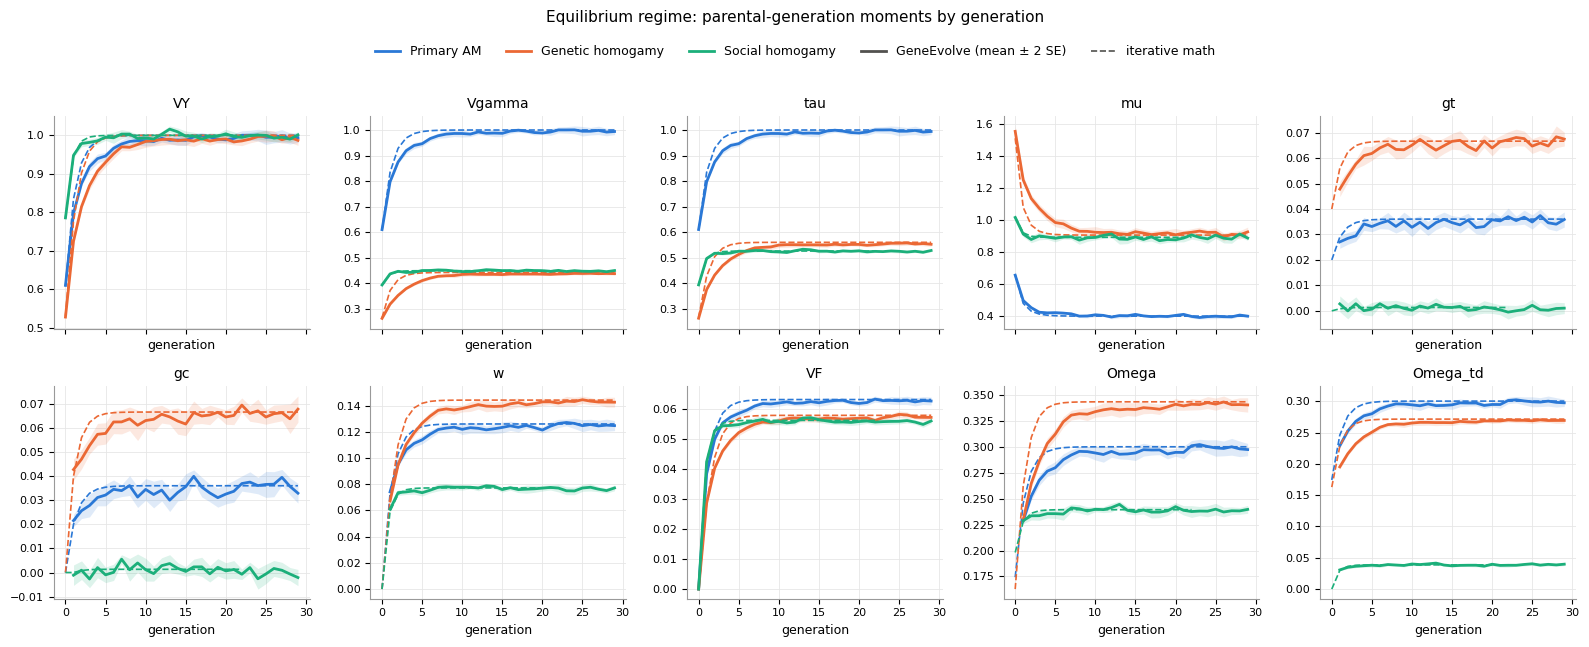

In [6]:
Q = ["VY", "Vgamma", "tau", "mu", "gt", "gc", "w", "VF", "Omega", "Omega_td"]
st = sim_traj[sim_traj["regime"] == "Eq"].groupby(["mechanism", "gen"])[Q].agg(["mean", "sem"])
mt = math_traj[math_traj["regime"] == "Eq"]
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True)
for ax, q in zip(axes.flat, Q):
    for mech in MECHS:
        s = st.loc[mech][q]
        ax.plot(s.index, s["mean"], color=MECH_COLOR[mech])
        ax.fill_between(s.index, s["mean"] - 2 * s["sem"], s["mean"] + 2 * s["sem"], color=MECH_COLOR[mech], alpha=.15, lw=0)
        mm = mt[(mt["mechanism"] == mech) & (mt["gen"] <= s.index.max())].sort_values("gen")
        ax.plot(mm["gen"], mm[q], color=MECH_COLOR[mech], lw=1.2, ls="--")
    ax.set_title(q); ax.set_xlabel("generation")
handles = [mpl.lines.Line2D([], [], color=MECH_COLOR[m], label=MECH_LABEL[m]) for m in MECHS] + [
    mpl.lines.Line2D([], [], color="#52514e", label="GeneEvolve (mean ± 2 SE)"),
    mpl.lines.Line2D([], [], color="#52514e", lw=1.2, ls="--", label="iterative math")]
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(.5, 1.03))
fig.suptitle("Equilibrium regime: parental-generation moments by generation", y=1.07, fontsize=11)
fig.tight_layout(); fig.savefig(f"{PLOTS}/eq_trajectories.png"); plt.show()

**What I see.** GeneEvolve approaches the fixed point more slowly than the recursion, most visibly for Ω and w
under genetic homogamy. Every quantity has plateaued by generation 15–20, and the plateau sits on the fixed point.
Thirty generations is enough.

For the DisEq regime the corresponding question is whether 20 generations of random mating bring vertical
transmission to its own fixed point. The next figure shows that burn-in: GeneEvolve mean ± 2 SE over 36 populations,
with the dashed line at the VT fixed point. It levels off after about 3 generations.

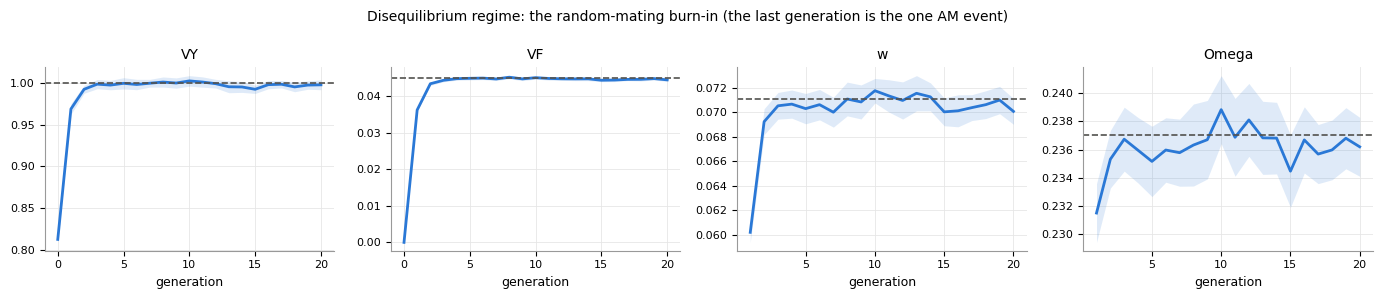

In [7]:
Qd = ["VY", "VF", "w", "Omega"]
sd = sim_traj[(sim_traj["regime"] == "DisEq") & (sim_traj["mechanism"] == "primary")].groupby("gen")[Qd].agg(["mean", "sem"])
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, q in zip(axes, Qd):
    s = sd[q]
    ax.plot(s.index, s["mean"], color="#2a78d6")
    ax.fill_between(s.index, s["mean"] - 2 * s["sem"], s["mean"] + 2 * s["sem"], color="#2a78d6", alpha=.15, lw=0)
    ax.axhline(M[("DisEq", "primary", q)], color="#52514e", lw=1.2, ls="--")
    ax.set_title(q); ax.set_xlabel("generation")
fig.suptitle("Disequilibrium regime: the random-mating burn-in (the last generation is the one AM event)", fontsize=10)
fig.tight_layout(); fig.savefig(f"{PLOTS}/diseq_burnin.png"); plt.show()

## 3. Does the simulation agree with the iterative math?

Here I take the population moments at the final mating and compare them with the math, one by one. They cover the
parents (within person), the spouses, and the offspring. The offspring moments include the DiffTrait offspring
trait (the `_o` rows).

**How to read the figure.** Each dot is (simulated − math) / math in percent, with ±2 SE across populations. A dot
on the dashed zero line means agreement. I leave out quantities whose true value is essentially zero; the gt and
gc terms under social homogamy are ~0.001, so their percentages mean nothing. Those quantities still appear in the
tables.

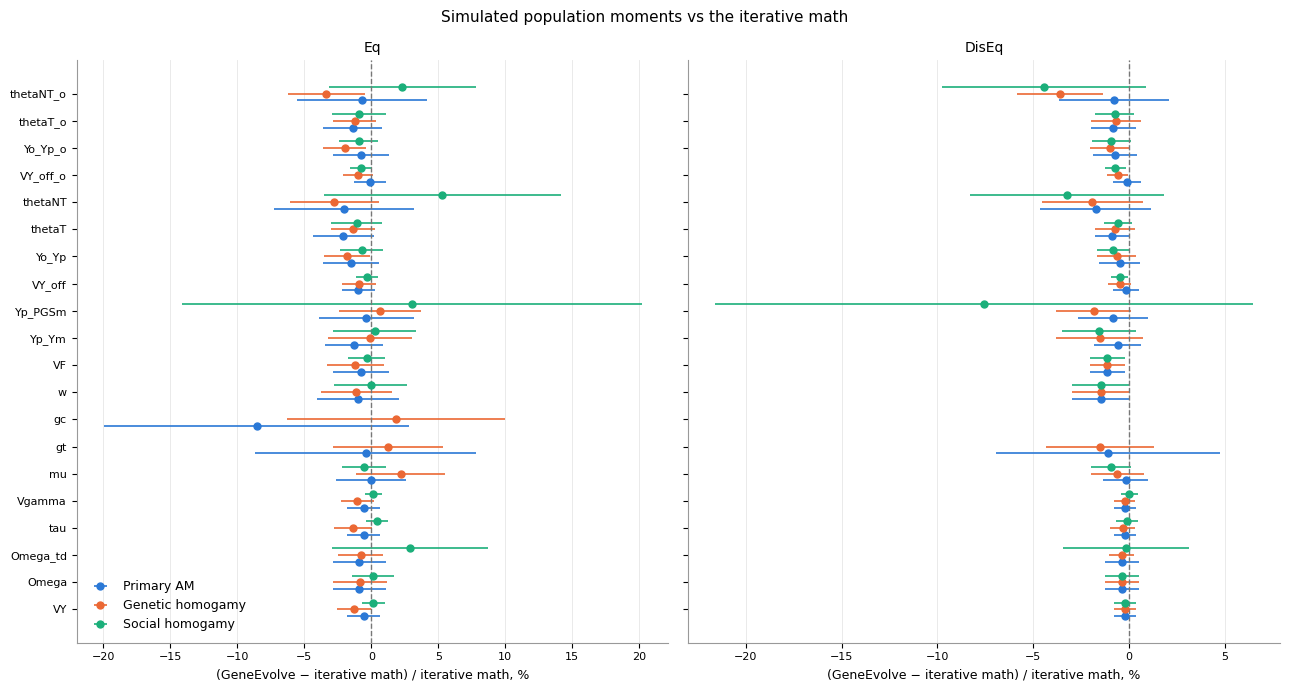

In [8]:
def math_val(regime, mech, key):
    if callable(key):
        return key(lambda k: M.get((regime, mech, k), np.nan))
    return M.get((regime, mech, key), np.nan)

BLOCKS = {
  "parents": ["VY", "VF", "Omega", "Gamma", "gc", "hc", "ic", "w", "v", "Omega_td", "Gamma_td", "zeta", "tau", "Vgamma"],
  "spouses": ["r_gamma", "mu", "gt", "ht", "it", "Yp_Ym", "Yp_PGSm", "Yp_LGSm", "Yp_Fm", "Fp_Fm"],
  "offspring": [("VY_off", "VY_off"), ("Yo_Yp", "Yo_Yp"), ("thetaT", "thetaT"), ("thetaNT", "thetaNT"),
                ("VY_off_o", "VY_o"), ("Yo_Yp_o", "Yo_Yp_o"), ("thetaT_o", "thetaT_o"), ("thetaNT_o", "thetaNT_o")],
}
S = sim_final.groupby(["regime", "mechanism", "quantity"])["value"].agg(["mean", "sem"])
rows = []
for regime in REGIMES:
    for mech in MECHS:
        for block, items in BLOCKS.items():
            for it in items:
                simq, mkey = it if isinstance(it, tuple) else (it, it)
                if (regime, mech, simq) not in S.index:
                    continue
                s = S.loc[(regime, mech, simq)]; mv = math_val(regime, mech, mkey)
                rows.append({"regime": regime, "mechanism": mech, "block": block, "quantity": simq, "math": mv,
                             "sim": s["mean"], "sim_SE": s["sem"],
                             "rel_pct": 100 * (s["mean"] - mv) / mv if abs(mv) > 1e-9 else np.nan,
                             "z": (s["mean"] - mv) / s["sem"]})
cmp = pd.DataFrame(rows)
cmp.to_csv(f"{OUT}/results/sim_vs_math.csv", index=False)

KEYS = ["VY", "Omega", "Omega_td", "tau", "Vgamma", "mu", "gt", "gc", "w", "VF", "Yp_Ym", "Yp_PGSm",
        "VY_off", "Yo_Yp", "thetaT", "thetaNT", "VY_off_o", "Yo_Yp_o", "thetaT_o", "thetaNT_o"]
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for ax, regime in zip(axes, REGIMES):
    t = cmp[(cmp["regime"] == regime) & cmp["quantity"].isin(KEYS) & (cmp["math"].abs() >= .005)]
    for k, mech in enumerate(MECHS):
        tt = t[t["mechanism"] == mech].set_index("quantity").reindex(KEYS)
        y = np.arange(len(KEYS)) + (k - 1) * .25
        ax.errorbar(tt["rel_pct"], y, xerr=200 * tt["sim_SE"] / tt["math"].abs(), fmt="o", ms=5, color=MECH_COLOR[mech],
                    elinewidth=1.2, capsize=0, label=MECH_LABEL[mech])
    ax.axvline(0, color="#777777", lw=1, ls="--")
    ax.set_yticks(range(len(KEYS))); ax.set_yticklabels(KEYS); ax.invert_yaxis()
    ax.set_xlabel("(GeneEvolve − iterative math) / iterative math, %"); ax.set_title(regime); ax.grid(axis="y", visible=False)
axes[0].legend(loc="lower left", frameon=False)
fig.suptitle("Simulated population moments vs the iterative math", fontsize=11)
fig.tight_layout(); fig.savefig(f"{PLOTS}/sim_vs_math.png"); plt.show()

**How to read the table.** Rows are moments; each regime × mechanism column shows the relative difference in
percent, with its z in brackets. Values beyond |z| = 3 are shaded. With 12 or 36 populations I'd expect one or two
|z| near 3 by chance across ~200 cells, and no systematic pattern.

In [9]:
cmp["cell"] = cmp.apply(lambda r: f"{r['rel_pct']:+.1f}% ({r['z']:+.1f})" if pd.notna(r["rel_pct"]) else f"≈0 ({r['z']:+.1f})", axis=1)
tab = cmp.pivot_table(index=["block", "quantity"], columns=["regime", "mechanism"], values="cell", aggfunc="first")
tab = tab.reindex(columns=pd.MultiIndex.from_product([REGIMES, MECHS]))
order = [(b, q if isinstance(q, str) else q[0]) for b, items in BLOCKS.items() for q in items]
tab = tab.reindex([o for o in order if o in tab.index])
zz = cmp.pivot_table(index=["block", "quantity"], columns=["regime", "mechanism"], values="z").reindex(index=tab.index, columns=tab.columns)
tab.style.apply(lambda _: np.where(zz.abs().to_numpy() > 3, "background-color: #f3d6cf", ""), axis=None)

**What I see.** The equilibrium moments agree within ~1–2% for all three mechanisms. That includes every Cascade
shortcut (Ω̃, τ, Vγ̃, µ) and the offspring moments. The disequilibrium moments agree within a few percent as well.

That second result only holds after I corrected the DisEq offspring algebra. The next table shows why. It puts the
formulas printed in the PDF (Part IV §18) and the ones in the original DisEq scripts next to the corrected forms and
the simulation, for the offspring generation of the DisEq regime.

In [10]:
orig_thetaNT = lambda g: 2 * g("a") * g("itol") + 2 * g("delta") * g("gt") + g("w")   # the old script form
FORMS = [  # (quantity, simulated, corrected, as printed in the PDF / old scripts)
    ("Ω₂ = θT per haplotype", "Omega_off", "thetaT", "PDF_Omega2", "PDF §18"),
    ("θNT per haplotype", "thetaNT", "thetaNT", lambda g: g("PDF_thetaNT2") / 2, "PDF §18 (÷2)"),
    ("θNT per haplotype", "thetaNT", "thetaNT", orig_thetaNT, "original DisEq scripts"),
    ("offspring VY", "VY_off", "VY_off", "PDF_VY2", "PDF §18"),
    ("offspring VY", "VY_off", "VY_off", "VY", "original DisEq scripts (= parents' VY)"),
    ("offspring w", "w_off", "w_o", "w", "original scripts / PDF Parts II, VI (parents' w)"),
    ("offspring VF", "VF_off", "VF_o", "VF", "original scripts / PDF Parts II, VI (parents' VF)"),
]
rows = []
for mech in MECHS:
    for label, simq, corr, other, source in FORMS:
        s = S.loc[("DisEq", mech, simq)]
        rows.append({"mechanism": mech, "quantity": label, "GeneEvolve": f"{s['mean']:.4f} ± {s['sem']:.4f}",
                     "corrected": math_val("DisEq", mech, corr), "as printed": math_val("DisEq", mech, other), "source of printed form": source})
pd.DataFrame(rows).round(4).set_index(["mechanism", "quantity"])

GeneEvolve  corrected  as printed                             source of printed form
mechanism quantity                                                                                                        
primary   Ω₂ = θT per haplotype  0.2715 ± 0.0012     0.2739      0.2965                                            PDF §18
          θNT per haplotype      0.0711 ± 0.0010     0.0724      0.0950                                       PDF §18 (÷2)
          θNT per haplotype      0.0711 ± 0.0010     0.0724      0.1164                             original DisEq scripts
          offspring VY           1.1190 ± 0.0038     1.1209      1.1665                                            PDF §18
          offspring VY           1.1190 ± 0.0038     1.1209      1.0000             original DisEq scripts (= parents' VY)
          offspring w            0.0979 ± 0.0007     0.0995      0.0711   original scripts / PDF Parts II, VI (parents' w)
          offspring VF           0.0627 ± 0.0003     0.0630      0.0450  original scripts / PDF Parts II, VI (parents' VF)
genetic   Ω₂ = θT per haplotype  0.2894 ± 0.0015     0.2915      0.3318                                            PDF §18
          θNT per haplotype      0.0884 ± 0.0012     0.0901      0.1304                                       PDF §18 (÷2)
          θNT per haplotype      0.0884 ± 0.0012     0.0901      0.1517                             original DisEq scripts
          offspring VY           1.1430 ± 0.0033     1.1486      1.2298                                            PDF §18
          offspring VY           1.1430 ± 0.0033     1.1486      1.0000             original DisEq scripts (= parents' VY)
          offspring w            0.0984 ± 0.0007     0.0995      0.0711   original scripts / PDF Parts II, VI (parents' w)
          offspring VF           0.0547 ± 0.0002     0.0551      0.0450  original scripts / PDF Parts II, VI (parents' VF)
social    Ω₂ = θT per haplotype  0.2393 ± 0.0009     0.2406      0.2417                                            PDF §18
          θNT per haplotype      0.0379 ± 0.0010     0.0392      0.0403                                       PDF §18 (÷2)
          θNT per haplotype      0.0379 ± 0.0010     0.0392      0.0734                             original DisEq scripts
          offspring VY           1.0182 ± 0.0022     1.0231      1.0254                                            PDF §18
          offspring VY           1.0182 ± 0.0022     1.0231      1.0000             original DisEq scripts (= parents' VY)
          offspring w            0.0754 ± 0.0006     0.0760      0.0711   original scripts / PDF Parts II, VI (parents' w)
          offspring VF           0.0554 ± 0.0002     0.0559      0.0450  original scripts / PDF Parts II, VI (parents' VF)

**How to read it.** For each offspring quantity, compare the `GeneEvolve` column with `corrected` and with
`as printed`.
* The corrected forms (derived directly from the model; see `../PDF_Errata.md`) land within ~2% of the simulation.
* The PDF's §18 forms count the AM-induced haplotype covariances twice.
* The original scripts used a two-haplotype θ, the parents' VY, and the parents' w/VF.

Under social homogamy the forms barely differ, because γ̃ carries almost no PGS.

## 4. Are the OpenMx estimates unbiased on simulated data?

This is the main test. I fit all 20 scripts to the pooled GeneEvolve trios, under each mechanism, and compare every
free parameter with the iterative-math truth. The pooled samples are ~48k trios for Eq and ~146k for DisEq.

**How to read the grid.** Each cell is one model: the largest |z| over its free parameters. With 10–19 free
parameters per model, a correctly specified model should mostly stay below ~3. Darker cells are worse.

Keep two things in mind:
* The SEs are small because the samples are large, so a 1–2% bias already reads as |z| ≈ 3.
* OpenMx warns that it does not check the Hessian for models with `mxConstraint`s. The SEs for tightly constrained
  directions can be too small, so a large |z| here is a flag to look at, not a verdict.

In [11]:
simd = free_params(est_sim)
sims = by_model(simd)
g = grid(sims, "max_abs_z")
g.style.format("{:.1f}", na_rep="(no SE)").background_gradient(cmap="Greys", vmin=0, vmax=12).set_caption("GeneEvolve fits: max |z| per model")

**How to read the z plots.** There is one figure per regime × trait and one panel per design. Each dot is a free
parameter under one mechanism, placed at its z. The dotted lines mark ±2. Dots far to either side of the dotted
lines are the parameters to look at. z is clipped at ±12 so a single outlier doesn't squash the panel.

In [12]:
def zplot(regime, trait):
    fig, axes = plt.subplots(1, 5, figsize=(18, 5.5))
    for ax, des in zip(axes, DESIGNS):
        t = simd[(simd["regime"] == regime) & (simd["trait"] == trait) & (simd["design"] == des)]
        params = sorted(t["parameter"].unique())
        for k, mech in enumerate(MECHS):
            tt = t[t["mechanism"] == mech].set_index("parameter").reindex(params)
            ax.scatter(tt["z"].clip(-12, 12), np.arange(len(params)) + (k - 1) * .25, s=24, color=MECH_COLOR[mech], zorder=3)
        for x in (-2, 2):
            ax.axvline(x, color="#999999", lw=1, ls=":")
        ax.axvline(0, color="#777777", lw=1, ls="--")
        ax.set_yticks(range(len(params))); ax.set_yticklabels(params, fontsize=7); ax.invert_yaxis()
        ax.set_xlim(-12.5, 12.5); ax.set_title(SHORT[des], fontsize=9); ax.set_xlabel("z"); ax.grid(axis="y", visible=False)
    handles = [mpl.lines.Line2D([], [], marker="o", ls="", color=MECH_COLOR[m], label=MECH_LABEL[m]) for m in MECHS]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(.5, 1.0))
    fig.suptitle(f"{regime}, {trait}: standardized bias of every free parameter", y=1.06, fontsize=11)
    fig.supxlabel("z = (estimate − truth) / SE, clipped at ±12; dotted lines at ±2", fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, .95)); fig.savefig(f"{PLOTS}/zbias_{regime}_{trait}.png"); plt.show()

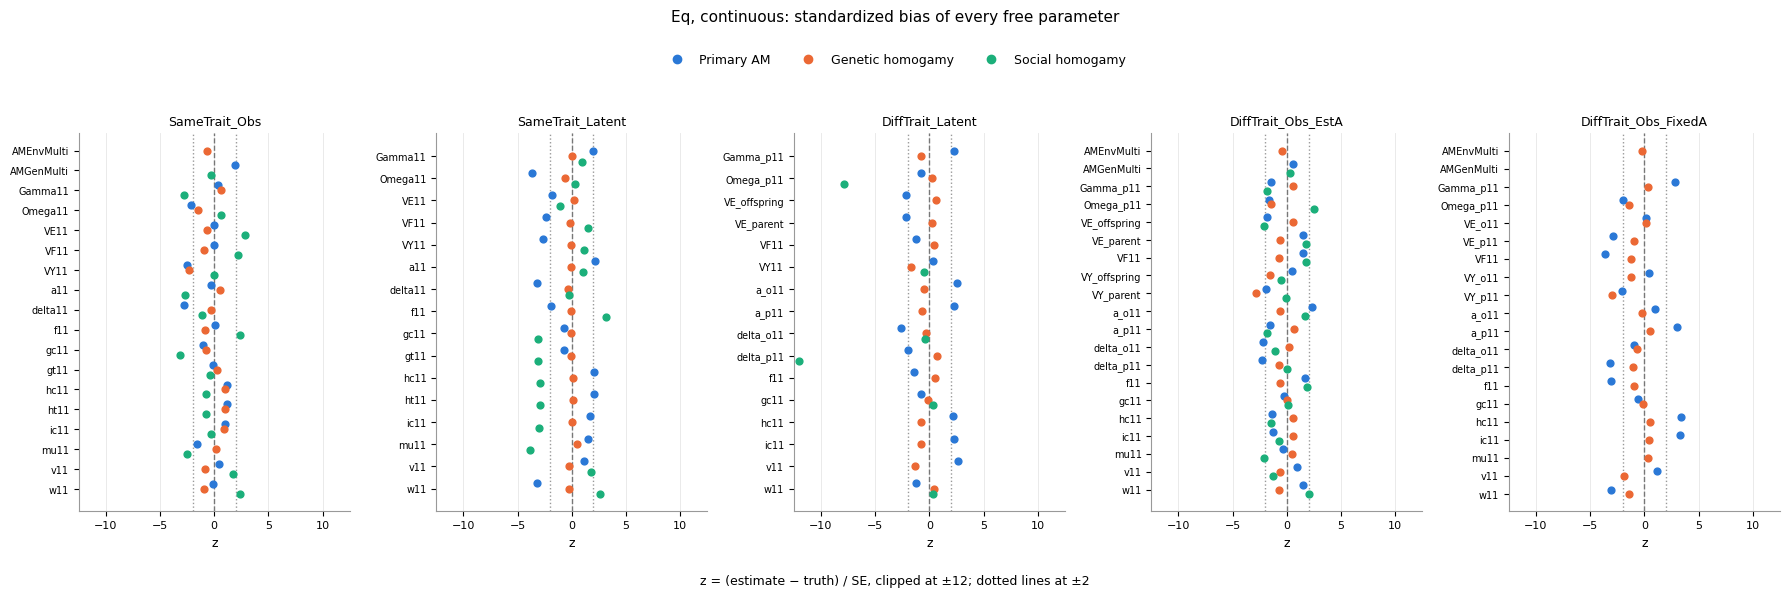

In [13]:
zplot('Eq', 'continuous')

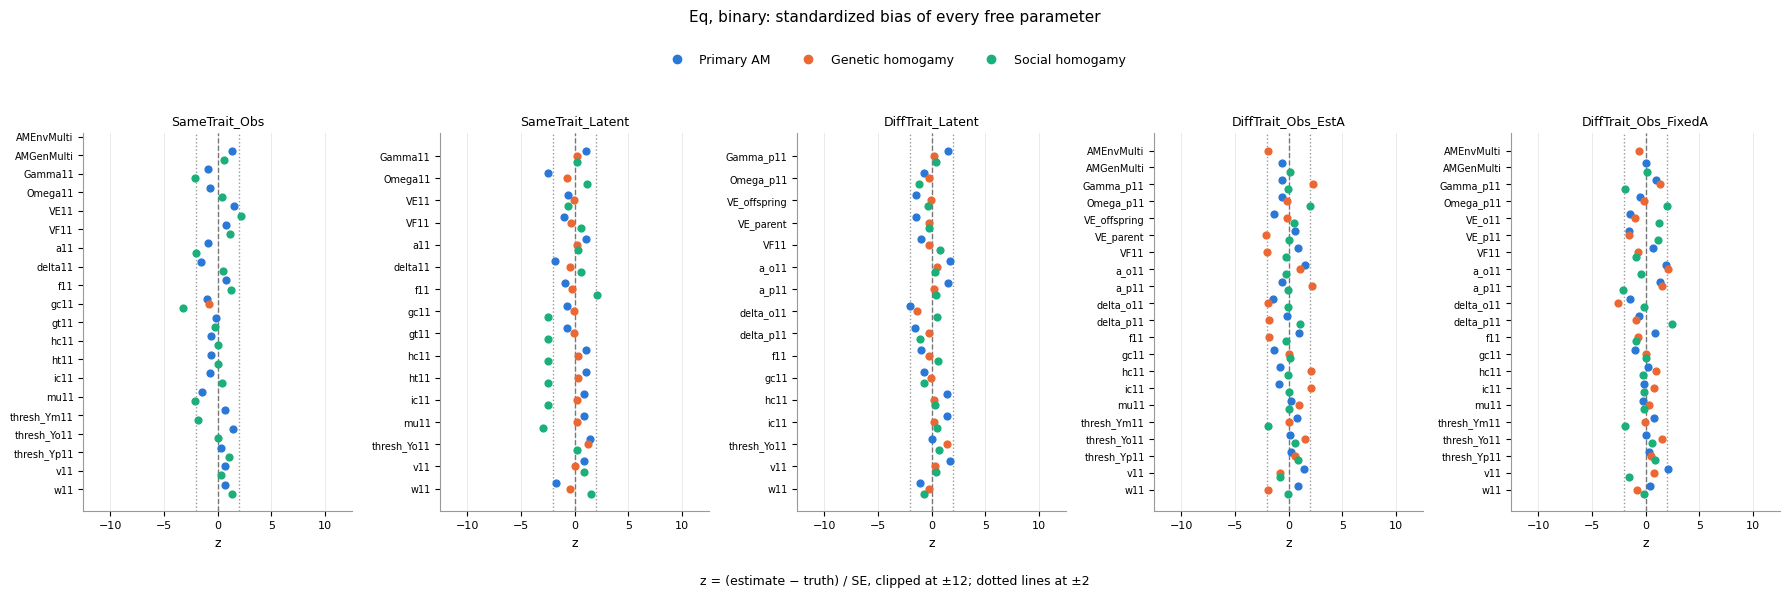

In [14]:
zplot('Eq', 'binary')

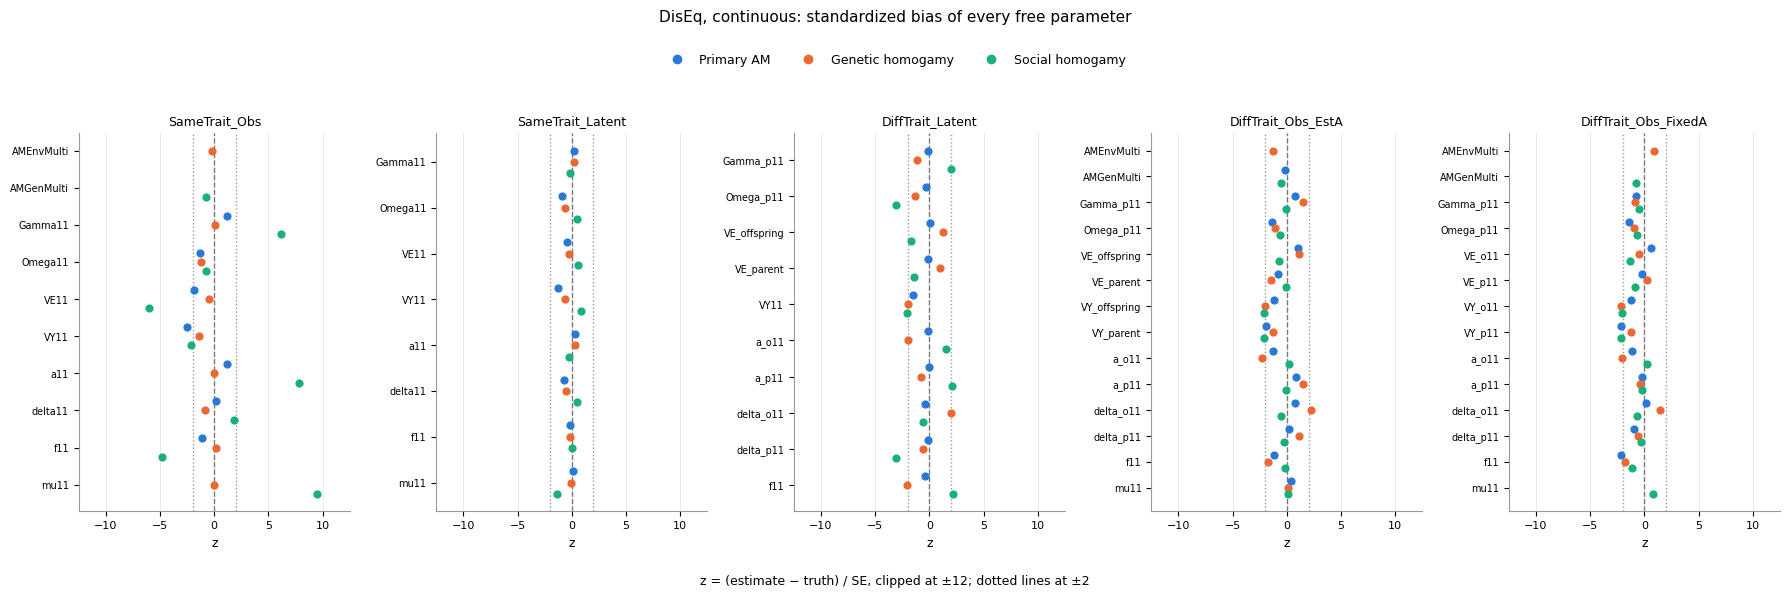

In [15]:
zplot('DisEq', 'continuous')

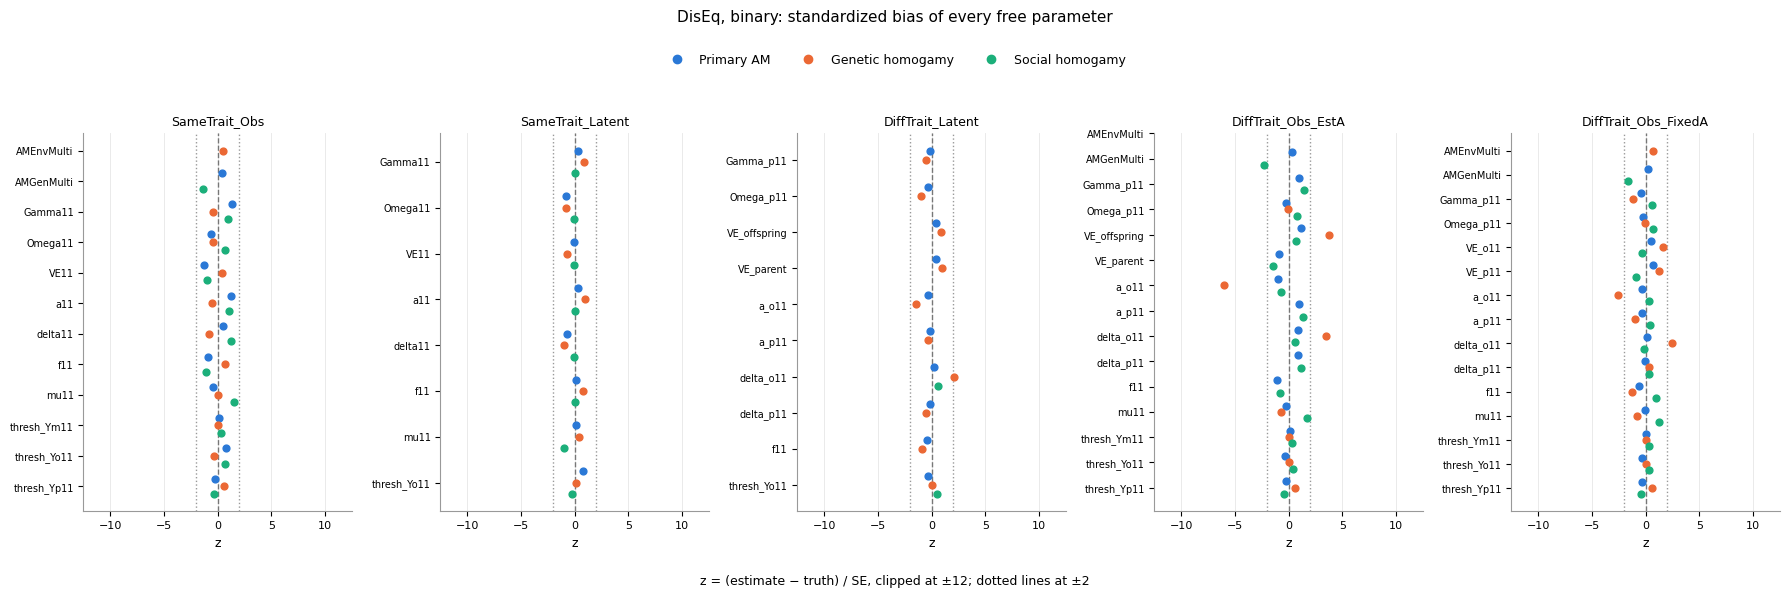

In [16]:
zplot('DisEq', 'binary')

**What I see.** Most models are unbiased under all three mechanisms. That includes the estimated mating
multiplier: AM_G ≈ 1 under primary AM, AM_G ≈ 0 under social homogamy, and AM_E ≈ 0 under genetic homogamy. Across
the ~860 free-parameter estimates, 9 models have a parameter beyond |z| = 3:
* **social homogamy** (6 models): both latent designs, and SameTrait_Obs. I take these apart in Section 5.
* **genetic homogamy, binary DisEq DiffTrait_Obs_EstA**: a_o is ~2% off (z = 6), i.e. the split of the offspring
  trait into a_o / δ_o / VE_o.
* **two isolated primary-AM cases** with |z| of 3.6–3.7: VF in Eq DiffTrait_Obs_FixedA, and Ω in Eq
  SameTrait_Latent. With ~860 estimates I'd expect two or three values beyond |z| = 3 by chance alone.

## 5. Why are some social-homogamy fits off?

**Is it off everywhere?** No. This table has one row per model and lists every social-homogamy parameter with
|z| > 3 on the pooled GeneEvolve data. Next to it are the worst |z| of the primary and genetic fits of the same
model, for comparison. An empty `social: params with |z|>3` cell means the social fit is fine.

In [17]:
rows = []
for (regime, trait, design), t in simd.groupby(["regime", "trait", "design"]):
    soc = t[t["mechanism"] == "social"]
    off = soc[soc["z"].abs() > 3].sort_values("z", key=abs, ascending=False)
    rows.append({"regime": regime, "trait": trait, "design": SHORT[design],
                 "social max|z|": soc["z"].abs().max(),
                 "social: params with |z|>3": ", ".join(f"{p} ({r:+.0f}%)" if pd.notna(r) else p
                                                       for p, r in zip(off["parameter"], off["rel_pct"])),
                 "primary max|z|": t.loc[t["mechanism"] == "primary", "z"].abs().max(),
                 "genetic max|z|": t.loc[t["mechanism"] == "genetic", "z"].abs().max()})
cross = pd.DataFrame(rows)
cross["_r"] = cross["regime"].map({"Eq": 0, "DisEq": 1})
cross.sort_values(["trait", "_r", "design"]).drop(columns="_r").set_index(["trait", "regime", "design"]).round(1)

social max|z|                          social: params with |z|>3  primary max|z|  genetic max|z|
trait      regime design                                                                                                                
binary     Eq     DiffTrait_Latent                1.1                                                                2.0             1.4
                  DiffTrait_Obs_EstA              2.0                                                                1.5             2.2
                  DiffTrait_Obs_FixedA            2.4                                                                2.0             2.6
                  SameTrait_Latent                2.9                                                                2.5             1.2
                  SameTrait_Obs                   3.2                                               gc11             1.6             0.8
           DisEq  DiffTrait_Latent                0.6                                                                0.4             2.0
                  DiffTrait_Obs_EstA              2.3                                                                1.1             6.0
                  DiffTrait_Obs_FixedA            1.7                                                                0.7             2.5
                  SameTrait_Latent                1.0                                                                0.9             1.0
                  SameTrait_Obs                   1.5                                                                1.4             0.8
continuous Eq     DiffTrait_Latent               13.2                 delta_p11 (-33%), Omega_p11 (-25%)             2.6             1.7
                  DiffTrait_Obs_EstA              2.5                                                                2.3             2.8
                  DiffTrait_Obs_FixedA            NaN                                                                3.7             3.0
                  SameTrait_Latent                3.9         mu11 (-137%), f11 (+26%), gt11, gc11, ic11             3.6             0.6
                  SameTrait_Obs                   3.1                                               gc11             2.8             2.3
           DisEq  DiffTrait_Latent                3.1                 delta_p11 (-33%), Omega_p11 (-29%)             1.5             2.1
                  DiffTrait_Obs_EstA              2.1                                                                1.9             2.3
                  DiffTrait_Obs_FixedA            2.1                                                                2.2             2.2
                  SameTrait_Latent                1.3                                                                1.3             0.6
                  SameTrait_Obs                   9.5  mu11 (+6%), a11 (+2%), Gamma11 (+1%), VE11 (-3...             2.5             1.4

All 10 binary models are fine under social homogamy. Among the continuous models, three patterns stand out:

1. **The two latent-parent designs** (SameTrait_Latent, DiffTrait_Latent), in both regimes.
2. **DisEq SameTrait_Obs**, where the pooled fit reads µ +6% at z = 9.5.
3. **Eq SameTrait_Obs** is only borderline on the pooled data (µ −14% at z −2.5; gc at z −3.1), but it looked
   systematic across populations, so I include it.

Eq DiffTrait_Obs_FixedA has no z at all because its Hessian failed. Its estimates are all within 2% of the truth.

The three patterns have different causes. They all trace back to one feature of social homogamy, so I start there.

### 5.1 How much of the mating the data can see

Under social homogamy spouses choose each other on F + E. The only genetic trace of that choice comes through the
part of F that is correlated with the genotype, which is small. The table shows this for the quantities that carry
the mating into the genetic data.
* Ω̃ = cov(γ̃, T) is how strongly the mating phenotype tracks a haplotype PGS.
* gt = Ω̃²µ is the covariance it induces between spouses' PGS (and, at equilibrium, between the two haplotypes
  within a person).
* cov(Yp, PGSm) = τµΩ̃ is the cross-spouse phenotype–PGS covariance.
* τ = cov(Y, γ̃) connects the phenotype to the mating phenotype.

**How to read it.** Compare the social column with the other two. Under social homogamy, Ω̃ drops from ~0.2–0.3 to
~0.04, so gt drops ~30–50-fold to about 0.001. At n ≈ 50,000 a covariance between two haplotype scores has a
sampling SE of about 0.002, so gt is invisible.

In [18]:
FOOT = {"Omega_td": "Ω̃ = cov(γ̃, T)", "gt": "gt = Ω̃²µ", "Yp_PGSm": "cov(Yp, PGSm) = τµΩ̃", "tau": "τ = cov(Y, γ̃)",
        "mu": "µ", "w": "w = cov(F, T)", "thetaNT": "θNT"}
foot = math[math["quantity"].isin(FOOT)].pivot_table(index="quantity", columns=["regime", "mechanism"], values="value")
foot = foot.reindex(list(FOOT)).reindex(columns=pd.MultiIndex.from_product([REGIMES, MECHS]))
foot.index = [FOOT[q] for q in foot.index]
foot.round(4)

Eq                   DisEq                
                     primary genetic  social primary genetic  social
Ω̃ = cov(γ̃, T)       0.3002  0.2714  0.0386  0.2370  0.2015  0.0356
gt = Ω̃²µ             0.0360  0.0667  0.0013  0.0225  0.0400  0.0011
cov(Yp, PGSm) = τµΩ̃  0.1201  0.1374  0.0181  0.0948  0.0948  0.0165
τ = cov(Y, γ̃)        1.0000  0.5595  0.5254  1.0000  0.4775  0.5225
µ                     0.4000  0.9049  0.8911  0.4000  0.9855  0.8872
w = cov(F, T)         0.1261  0.1443  0.0773  0.0711  0.0711  0.0711
θNT                   0.1259  0.1807  0.0413  0.0724  0.0901  0.0392

### 5.2 Latent-parent designs: the social-homogamy parameters are not identified in practice

With latent parents, the model sees mating only through the haplotype covariances (gt, and gc at equilibrium).
Under primary AM and genetic homogamy, gt = Ω̃²µ is large enough to pin down µ (SameTrait_Latent) and to separate
Ω_p from f (DiffTrait_Latent, where µ is fixed). Under social homogamy gt ≈ 0.001, so the data only determine
combinations of these parameters. For example, θNT fixes w = 2f(Ω_p + τµΩ̃), but not f and Ω_p separately.

**How to read the table.** It shows the relative error (%) of the affected parameters in three fits:
* the social fit to exact data;
* the social fit to GeneEvolve data;
* the primary-AM fit to GeneEvolve data, for contrast.

Exact data recover the truth, so the model is coded right and technically identified. With real sampling noise the
social estimates move by 25–140%. The per-population fits in the last column show the same thing: for Eq
SameTrait_Latent under social homogamy, µ has an SD of about 2 across populations of 4,000 trios, around a true
value of 0.89.

In [19]:
KEY = {"SameTrait_LatentYPYM": ["mu11", "f11", "VE11", "a11"],
       "DiffTrait_LatentYPYM": ["delta_p11", "a_p11", "VE_parent", "f11"]}
mv, sv = free_params(est_mvn), simd
rows = []
for des, ps in KEY.items():
    for p in ps:
        for reg in REGIMES:
            def rel(d, mech):
                x = d[(d["trait"] == "continuous") & (d["design"] == des) & (d["regime"] == reg) & (d["mechanism"] == mech) & (d["parameter"] == p)]
                return x["rel_pct"].iloc[0] if len(x) else np.nan
            ppx = perpop[(perpop["design"] == des) & (perpop["regime"] == reg) & (perpop["mechanism"] == "social") & (perpop["parameter"] == p)]
            rows.append({"design": SHORT[des], "parameter": p, "regime": reg,
                         "social, exact data": rel(mv, "social"), "social, GeneEvolve": rel(sv, "social"),
                         "primary, GeneEvolve": rel(sv, "primary"),
                         "social: SD across pops / truth": ppx["estimate"].std() / abs(ppx["true"].iloc[0]) if len(ppx) else np.nan})
lat = pd.DataFrame(rows).set_index(["design", "parameter", "regime"])
lat.style.format({c: "{:+.1f}%" for c in lat.columns[:3]} | {lat.columns[3]: "{:.2f}"}, na_rep="—")

### 5.3 DisEq SameTrait_Obs: the standard errors are too small, the estimate is fine

To find out whether this is bias or noise, I fit every GeneEvolve population on its own (`04_social_homogamy.R`,
~4,000 trios each; 12 Eq and 36 DisEq populations per mechanism). This gives me the actual sampling distribution of
each estimate.

**How to read the figure.** Each dot is one parameter under one mechanism. It is placed at the ratio of the SD of its
estimates across populations to the mean SE that OpenMx reported.
* A ratio of 1 (dashed line) means the reported SEs are honest.
* A ratio of 5 means the SEs are 5× too small, so every z computed from them is 5× too large.

The x-axis is logarithmic and clipped at 30.

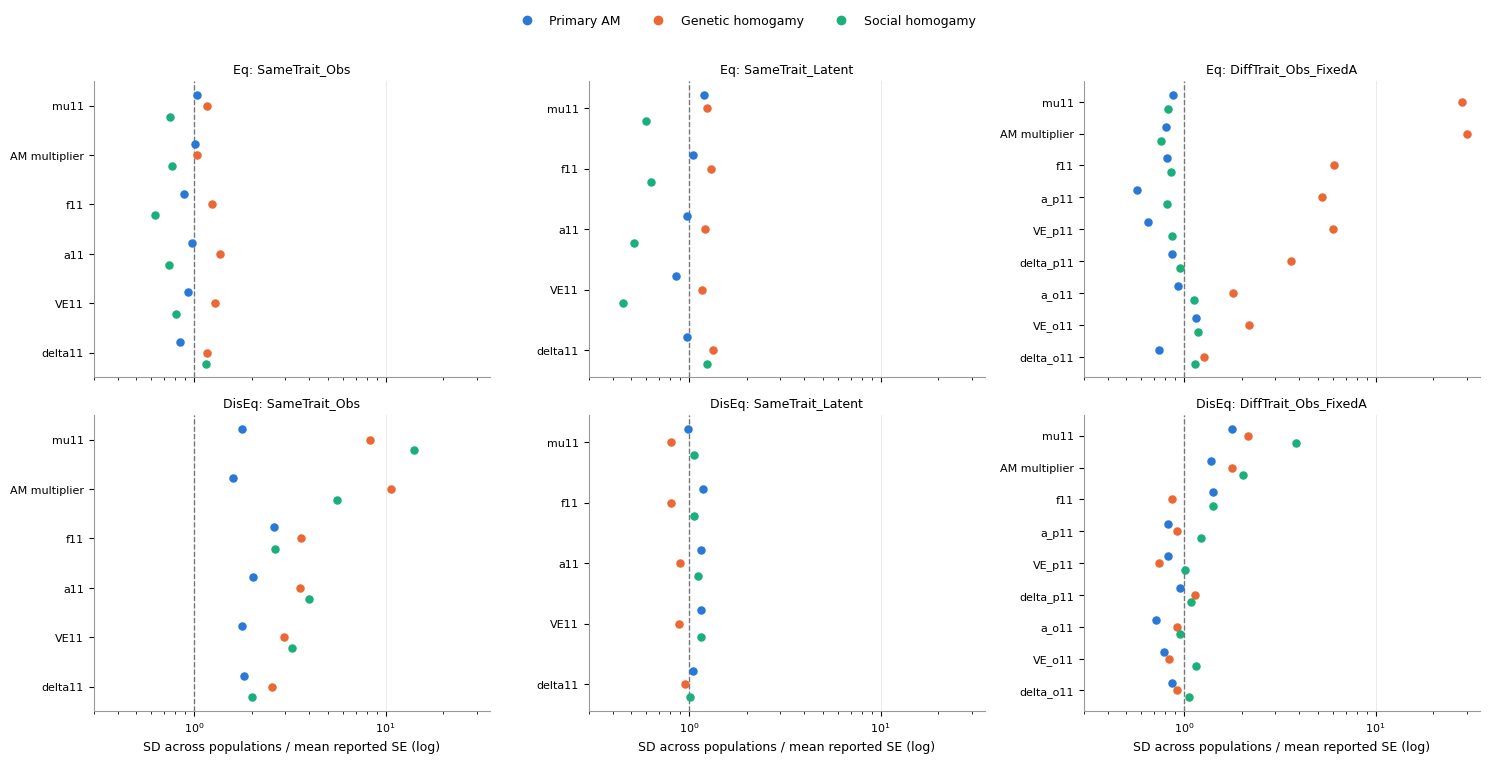

In [20]:
pp = perpop[perpop["true"].notna() & ~perpop["parameter"].fillna("").str.startswith("mean") & (perpop["statusCode"] != "ERROR")].copy()
STRUCT = ["delta11", "a11", "VE11", "f11", "mu11", "AMGenMulti", "AMEnvMulti",
          "delta_p11", "a_p11", "VE_p11", "delta_o11", "a_o11", "VE_o11"]
cal = pp[pp["parameter"].isin(STRUCT)].groupby(["regime", "design", "mechanism", "parameter"]).apply(lambda x: pd.Series({
    "pops": len(x), "truth": x["true"].iloc[0], "mean est": x["estimate"].mean(),
    "bias %": 100 * (x["estimate"].mean() - x["true"].iloc[0]) / x["true"].iloc[0] if abs(x["true"].iloc[0]) > .01 else np.nan,
    "z_bias": (x["estimate"].mean() - x["true"].iloc[0]) / (x["estimate"].std() / np.sqrt(len(x))),
    "SD across pops": x["estimate"].std(), "mean SE": x["SE"].mean()}), include_groups=False).reset_index()
cal["SD / SE"] = cal["SD across pops"] / cal["mean SE"]
cal["parameter"] = cal["parameter"].replace({"AMGenMulti": "AM multiplier", "AMEnvMulti": "AM multiplier"})
PD = ["SameTrait_ObservedYPYM", "SameTrait_LatentYPYM", "DiffTrait_ObservedYPYM_FixedAParent"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
for i, reg in enumerate(REGIMES):
    for j, des in enumerate(PD):
        ax = axes[i, j]; t = cal[(cal["regime"] == reg) & (cal["design"] == des)]
        params = [p for p in ["mu11", "AM multiplier", "f11", "a11", "VE11", "delta11", "a_p11", "VE_p11", "delta_p11", "a_o11", "VE_o11", "delta_o11"] if p in set(t["parameter"])]
        for k, mech in enumerate(MECHS):
            tt = t[t["mechanism"] == mech].set_index("parameter").reindex(params)
            ax.scatter(tt["SD / SE"].clip(upper=30), np.arange(len(params)) + (k - 1) * .22, s=26, color=MECH_COLOR[mech], zorder=3)
        ax.axvline(1, color="#777777", lw=1, ls="--")
        ax.set_xscale("log"); ax.set_xlim(.3, 35)
        ax.set_yticks(range(len(params))); ax.set_yticklabels(params, fontsize=8); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
        ax.set_title(f"{reg}: {SHORT[des]}", fontsize=9)
        if i == 1: ax.set_xlabel("SD across populations / mean reported SE (log)")
handles = [mpl.lines.Line2D([], [], marker="o", ls="", color=MECH_COLOR[m], label=MECH_LABEL[m]) for m in MECHS]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, .96)); fig.savefig(f"{PLOTS}/se_calibration.png"); plt.show()

In **DisEq SameTrait_Obs** the reported SEs are too small under every mechanism, and badly so under social and
genetic homogamy.
* For µ, the SD across populations is 14× the reported SE under social homogamy, 8× under genetic homogamy and
  1.8× under primary AM.
* For a, VE and f the ratio is 2–4×.

DisEq DiffTrait_Obs_FixedA shows a milder version: µ at 1.8–3.8×, and the multiplier at 1.4–2×.

In Eq, and in SameTrait_Latent, the ratios are close to 1. Eq DiffTrait_Obs_FixedA under genetic homogamy looks
extreme only because two of its 12 per-population fits failed (status red) and landed far off. Without them, its
ratios are 1.4–2.3.

I don't know yet exactly why the DisEq SEs are off when the Eq ones are fine. OpenMx warns that it does not check
the Hessian of models with `mxConstraint`s, and the DisEq scripts use a different constraint set from the Eq ones
(Ω is constrained in DisEq, free in Eq). Whatever the cause, the spread across populations shows it plainly, and
the profile likelihood below confirms it.

The profile likelihood gives an independent check. On the pooled data I fix µ at values from 0.7× to 1.3× its
truth, re-optimize everything else, and record how much −2LL rises. For one parameter, a rise of 3.84 marks the edge
of a 95% confidence interval, and this doesn't depend on the Hessian at all.

**How to read the figure.** A narrow, steep curve means the data determine µ well; a wide, shallow one means many
values fit about equally well. The dashed vertical line is the truth. If the curve at the truth stays under the
dotted 3.84 line, the truth is inside the 95% interval.

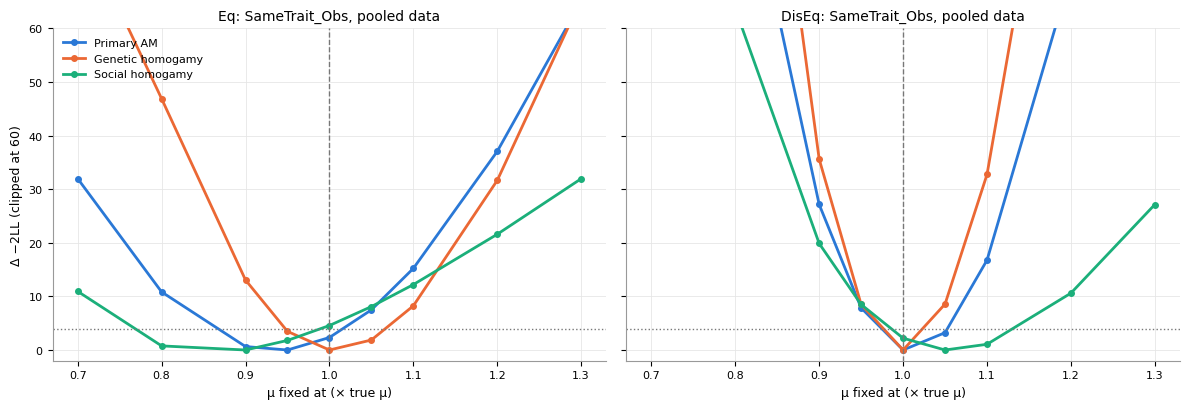

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, regime in zip(axes, REGIMES):
    for mech in MECHS:
        p = profile[(profile["regime"] == regime) & (profile["mechanism"] == mech)].sort_values("mu_ratio")
        ax.plot(p["mu_ratio"], p["minus2LL"] - p["minus2LL"].min(), "o-", color=MECH_COLOR[mech], ms=4, label=MECH_LABEL[mech])
    ax.axhline(3.84, color="#777777", lw=1, ls=":"); ax.axvline(1, color="#777777", lw=1, ls="--")
    ax.set_ylim(-2, 60); ax.set_title(f"{regime}: SameTrait_Obs, pooled data"); ax.set_xlabel("µ fixed at (× true µ)")
axes[0].set_ylabel("Δ −2LL (clipped at 60)"); axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(f"{PLOTS}/profile_mu.png"); plt.show()

The next table turns each profile into numbers:
* the best-fitting µ on the grid;
* Δ−2LL at the truth;
* the approximate 95% interval, from linear interpolation of the Δ−2LL = 3.84 crossings;
* the SE that interval implies (half its width / 1.96).

That last value sits next to the SE OpenMx reported for the pooled fit and the SE implied by the spread of the
per-population estimates (SD / √populations).

In [22]:
def crossing(x, d, side):
    # linear interpolation of where d crosses 3.84 on one side of the minimum
    i0 = int(np.argmin(d)); idx = range(i0, -1, -1) if side == "lo" else range(i0, len(d))
    prev = i0
    for i in idx:
        if d[i] > 3.84:
            return x[prev] + (3.84 - d[prev]) * (x[i] - x[prev]) / (d[i] - d[prev])
        prev = i
    return np.nan
rows = []
for (reg, mech), p in profile.groupby(["regime", "mechanism"]):
    p = p.sort_values("mu_ratio"); x = p["mu_ratio"].to_numpy(); d = (p["minus2LL"] - p["minus2LL"].min()).to_numpy()
    lo, hi = crossing(x, d, "lo"), crossing(x, d, "hi")
    pooled = simd[(simd["regime"] == reg) & (simd["mechanism"] == mech) & (simd["trait"] == "continuous") &
                  (simd["design"] == "SameTrait_ObservedYPYM") & (simd["parameter"] == "mu11")].iloc[0]
    c = cal[(cal["regime"] == reg) & (cal["mechanism"] == mech) & (cal["design"] == "SameTrait_ObservedYPYM") & (cal["parameter"] == "mu11")].iloc[0]
    rows.append({"regime": reg, "mechanism": mech, "best µ / true": x[np.argmin(d)], "Δ−2LL at truth": d[np.argmin(np.abs(x - 1))],
                 "95% from": lo, "to": hi, "profile SE (% of µ)": 100 * (hi - lo) / 2 / 1.96,
                 "OpenMx SE (% of µ)": 100 * pooled["SE"] / pooled["true"],
                 "SD/√pops (% of µ)": 100 * c["SD across pops"] / np.sqrt(c["pops"]) / c["truth"],
                 "pooled µ error (%)": pooled["rel_pct"]})
prof_tab = pd.DataFrame(rows).set_index(["regime", "mechanism"]).reindex(pd.MultiIndex.from_product([REGIMES, MECHS]))
prof_tab.round(2)

best µ / true  Δ−2LL at truth  95% from    to  profile SE (% of µ)  OpenMx SE (% of µ)  SD/√pops (% of µ)  pooled µ error (%)
Eq    primary           0.95            2.33      0.87  1.01                 3.72                4.05               4.39               -6.43
      genetic           1.00            0.00      0.95  1.07                 3.00                3.10               4.03                0.62
      social            0.90            4.56      0.77  0.99                 5.54                5.69               4.33              -14.09
DisEq primary           1.00            0.00      0.98  1.05                 1.96                 NaN               1.83                1.00
      genetic           1.00            0.00      0.98  1.02                 1.15                1.71               1.52               -0.09
      social            1.05            2.21      0.99  1.13                 3.62                0.60               3.76                5.70

For DisEq social, the profile and the population spread agree: the pooled µ has a real SE of about 3.6–3.8%, not
the 0.6% OpenMx reports. On that scale, the +5.7% deviation that looked like z = 9.5 is about 1.5 SE. The truth sits
inside the 95% profile interval, with Δ−2LL = 2.2. In Eq, all three SE estimates agree with one another.

Eq social is the one profile whose truth falls just outside the 95% interval. Its best µ is 0.9× the truth, with
Δ−2LL = 4.6 at the truth. That is the pooled Eq shift I take up in 5.4.

The other DisEq SameTrait_Obs parameters behave the same way. Measured against the actual spread, their mean
across 36 populations stays within 2.5 SE of the truth:

In [23]:
d = cal[(cal["design"] == "SameTrait_ObservedYPYM") & (cal["regime"] == "DisEq")]
d.pivot_table(index="parameter", columns="mechanism", values=["bias %", "z_bias", "SD / SE"]).reindex(columns=MECHS, level=1).round(2)

SD / SE                 bias %                 z_bias               
mechanism     primary genetic social primary genetic social primary genetic social
parameter                                                                         
AM multiplier    1.61   10.62   5.60   -0.05     NaN    NaN   -0.03   -0.65   0.09
VE11             1.78    2.96   3.23   -2.18   -0.82  -2.87   -1.59   -0.60  -1.99
a11              2.04    3.58   3.96    1.28   -0.12   2.36    0.73   -0.07   1.51
delta11          1.83    2.56   2.01    0.07   -0.48   0.65    0.13   -0.71   1.22
f11              2.61    3.61   2.64   -2.95    0.33  -5.09   -0.84    0.10  -1.86
mu11             1.78    8.33  13.97    1.34   -0.00   9.02    0.73   -0.00   2.40

### 5.4 Eq SameTrait_Obs: a flat direction and some unlucky noise

In Eq, the SEs are honest (the figure in 5.3), yet under social homogamy the per-population estimates lean one way:
* a is below the truth in 11 of 12 populations;
* VE and f are above it in 11 and 10 of 12.

**How to read the table.** It is the same summary as above, for Eq SameTrait_Obs:
* `bias %` is the mean over populations relative to the truth;
* `z_bias` is that mean divided by its SE across populations (SD / √12).

In [24]:
d = cal[(cal["design"] == "SameTrait_ObservedYPYM") & (cal["regime"] == "Eq")]
d.pivot_table(index="parameter", columns="mechanism", values=["bias %", "z_bias", "SD / SE"]).reindex(columns=MECHS, level=1).round(2)

SD / SE                 bias %                 z_bias               
mechanism     primary genetic social primary genetic social primary genetic social
parameter                                                                         
AM multiplier    1.02    1.04   0.77    8.70     NaN    NaN    1.97   -1.05  -0.26
VE11             0.93    1.29   0.81   -0.10   -2.09   7.54   -0.04   -0.52   3.54
a11              0.97    1.36   0.74   -1.00    1.13  -9.09   -0.35    0.23  -3.75
delta11          0.85    1.17   1.16   -3.33   -0.31  -1.36   -3.27   -0.22  -1.05
f11              0.89    1.24   0.63    0.50   -7.79  11.64    0.09   -0.71   3.83
mu11             1.03    1.18   0.75   -5.45   -0.34 -12.24   -1.24   -0.08  -2.83

The estimates move together (a down, VE and f up, µ down). That is the direction in which the model can trade the
additive genetic part of Y for its F + E part and still fit the phenotypic covariances. Under social homogamy,
τ = cov(Y, γ̃) = VE + VF + δw + av is made up of exactly those parts, so µ slides along with them.

To find out which data moments push the fit along this direction, I use `05_moment_sensitivity.R`. For each
distinct moment of the 7×7 matrix, it fits the model to the *true* implied covariance matrix with only that
moment's cells replaced by the pooled GeneEvolve values. It uses the same n and starts at the truth. The row `all`
is the fit to the pooled GeneEvolve covariance matrix itself, which reproduces the raw-data fit.

**How to read the figure.** There is one panel per parameter. Each bar is the shift in that parameter, in % of the
truth, that one moment's deviation produces on its own. Green is Eq social, blue is Eq primary. The first table
below lists how far each moment in the pooled data is from its model value, in % and in z.

In [25]:
MOMENT_CELLS = {"VY": [(0, 0), (1, 1)], "Yp_Ym": [(0, 1)], "Yo_Yp": [(0, 2), (1, 2)], "VY_o": [(2, 2)],
                "Omega": [(0, 3), (0, 4), (1, 5), (1, 6)], "Yp_PGSm": [(0, 5), (0, 6), (1, 3), (1, 4)],
                "thetaT": [(2, 3), (2, 5)], "thetaNT": [(2, 4), (2, 6)], "var_T": [(3, 3), (4, 4), (5, 5), (6, 6)],
                "gc": [(3, 4), (5, 6)], "gt": [(3, 5), (3, 6), (4, 5), (4, 6)]}
COLS7 = ["Yp1", "Ym1", "Yo1", "Tp1", "NTp1", "Tm1", "NTm1"]
def implied7(regime, mech):
    g = lambda q: M[(regime, mech, q)]
    VYo = g("VY") if regime == "Eq" else g("VY_off"); gc = g("gc") if regime == "Eq" else 0.0; k = g("k")
    return {"VY": g("VY"), "Yp_Ym": g("Yp_Ym"), "Yo_Yp": g("Yo_Yp"), "VY_o": VYo, "Omega": g("Omega"), "Yp_PGSm": g("Yp_PGSm"),
            "thetaT": g("thetaT"), "thetaNT": g("thetaNT"), "var_T": k + gc, "gc": gc, "gt": g("gt")}
rows = []
for mech in MECHS:
    X = pd.read_csv(f"{OUT}/data/Eq_{mech}_SameTrait_Observed.tsv", sep="\t")[COLS7].to_numpy(); n = len(X); S = np.cov(X.T)
    tv = implied7("Eq", mech)
    for m, cells in MOMENT_CELLS.items():
        s = np.mean([S[i, j] for i, j in cells]); t = tv[m]
        # approximate SE of the averaged covariance (normal theory; cells treated as independent)
        se = np.sqrt(np.mean([(S[i, i] * S[j, j] + S[i, j] ** 2) for i, j in cells]) / n / len(cells))
        rows.append({"mechanism": mech, "moment": m, "model value": t, "pooled data": s,
                     "rel %": 100 * (s - t) / t if abs(t) > 1e-3 else np.nan, "z": (s - t) / se})
mom = pd.DataFrame(rows)
mom.pivot_table(index="moment", columns="mechanism", values=["model value", "rel %", "z"], sort=False).reindex(columns=MECHS, level=1).round(3)

model value                  rel %                        z               
mechanism     primary genetic social primary genetic   social primary genetic social
moment                                                                              
VY              1.000   1.000  1.000  -0.995  -1.384   -0.318  -2.212  -3.099 -0.704
Yp_Ym           0.400   0.283  0.246  -1.287  -0.129    0.113  -1.064  -0.079  0.060
Yo_Yp           0.576   0.584  0.442  -1.546  -0.967   -0.178  -2.437  -1.536 -0.224
VY_o            1.000   1.000  1.000  -1.693  -0.270    0.606  -2.682  -0.422  0.938
Omega           0.300   0.344  0.239  -1.291  -1.133    0.188  -2.175  -2.099  0.267
Yp_PGSm         0.120   0.137  0.018  -0.401   0.635    2.737  -0.288   0.509  0.310
thetaT          0.300   0.344  0.239  -3.047  -1.360   -0.337  -3.648  -1.779 -0.338
thetaNT         0.126   0.181  0.041   0.172   0.640    5.320   0.092   0.467  0.962
var_T           0.536   0.567  0.501  -0.408  -0.616   -0.733  -1.277  -1.936 -2.299
gc              0.036   0.067  0.001  -1.155   2.102 -266.386  -0.242   0.771 -2.218
gt              0.036   0.067  0.001  -0.559   1.208  -23.268  -0.166   0.627 -0.274

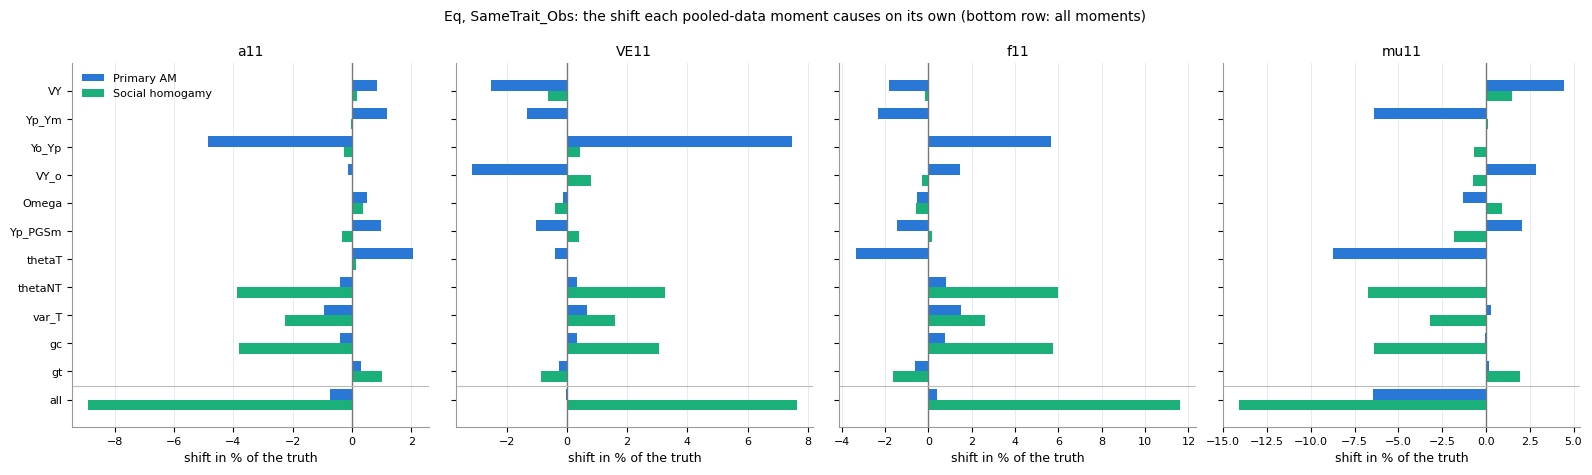

In [26]:
sens = pd.read_csv(f"{OUT}/results/moment_sensitivity.csv")
sens = sens[sens["parameter"].isin(["a11", "VE11", "f11", "mu11"])].copy()
sens["rel"] = 100 * (sens["estimate"] - sens["true"]) / sens["true"]
ORDER = ["VY", "Yp_Ym", "Yo_Yp", "VY_o", "Omega", "Yp_PGSm", "thetaT", "thetaNT", "var_T", "gc", "gt", "all"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.8), sharey=True)
for ax, par in zip(axes, ["a11", "VE11", "f11", "mu11"]):
    for k, mech in enumerate(["primary", "social"]):
        t = sens[(sens["regime"] == "Eq") & (sens["mechanism"] == mech) & (sens["parameter"] == par)].set_index("which").reindex(ORDER)
        ax.barh(np.arange(len(ORDER)) + (k - .5) * .38, t["rel"], height=.38, color=MECH_COLOR[mech], label=MECH_LABEL[mech])
    ax.axvline(0, color="#777777", lw=1); ax.axhline(len(ORDER) - 1.5, color="#bbbbbb", lw=.8)
    ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER); ax.grid(axis="y", visible=False)
    ax.set_title(par); ax.set_xlabel("shift in % of the truth")
axes[0].invert_yaxis()   # the y axis is shared, so invert it once
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Eq, SameTrait_Obs: the shift each pooled-data moment causes on its own (bottom row: all moments)", fontsize=10)
fig.tight_layout(); fig.savefig(f"{PLOTS}/moment_sensitivity.png"); plt.show()

For Eq social, three moments produce essentially the whole shift, and all three belong to the PGS side of the
data:
* **θNT = cov(Yo, NTp)**, 5% high;
* **the within-person gc = cov(Tp, NTp)**, about −0.002 against a true +0.0013;
* **var(T)**, 0.7% low.

Each is within ~1–2.5 sampling SE of its model value. They push in the same direction because under social
homogamy θNT is the only moment that measures w (θNT = 2δgc + 2a·ic + ½w). A lower gc or var(T), or a higher θNT,
raises the estimated w, and the model has to pay for a larger w with more f. That moves VE, a and µ along the ridge.

Under primary AM the estimates are just as sensitive, but mostly to other moments (cov(Yo, Yp) and θT). In that
sample the pushes from different moments largely cancel.

So is it chance, or something GeneEvolve does under social homogamy? To answer that I simulated 24 more Eq
social-homogamy populations with the same code and seeds 13–36 (`06_replicate_eq_social.py/.R`) and fit them the
same way.

In [27]:
rep = pd.read_csv(f"{OUT}/results/replication_eq_social.csv")
rep = rep[rep["parameter"].isin(["a11", "VE11", "f11", "mu11", "delta11", "Gamma11", "gc11"])]
first = perpop[(perpop["regime"] == "Eq") & (perpop["mechanism"] == "social") & (perpop["design"] == "SameTrait_ObservedYPYM") &
               perpop["parameter"].isin(rep["parameter"].unique())]
pooled_first = simd[(simd["regime"] == "Eq") & (simd["mechanism"] == "social") & (simd["trait"] == "continuous") &
                    (simd["design"] == "SameTrait_ObservedYPYM")].set_index("parameter")
def summ(x):
    t = x["true"].iloc[0]; n = len(x); sd = x["estimate"].std()
    return pd.Series({"pops": n, "mean bias %": 100 * (x["estimate"].mean() - t) / t if abs(t) > .01 else np.nan,
                      "z_bias": (x["estimate"].mean() - t) / (sd / np.sqrt(n)), "share below truth": (x["estimate"] < t).mean()})
tab = pd.concat({"populations 1–12": first.groupby("parameter").apply(summ, include_groups=False),
                 "populations 13–36": rep[rep["fit"] == "population"].groupby("parameter").apply(summ, include_groups=False)}, axis=1)
tab[("pooled fit", "1–12 (n≈48k) bias %")] = [100 * (pooled_first.loc[p, "estimate"] / pooled_first.loc[p, "true"] - 1) if abs(pooled_first.loc[p, "true"]) > .01 else np.nan for p in tab.index]
rp = rep[rep["fit"] == "pooled"].set_index("parameter")
tab[("pooled fit", "13–36 (n≈97k) bias %")] = [100 * (rp.loc[p, "estimate"] / rp.loc[p, "true"] - 1) if abs(rp.loc[p, "true"]) > .01 else np.nan for p in tab.index]
tab.round(2)

populations 1–12                                      populations 13–36                                               pooled fit                     
                      pops mean bias % z_bias share below truth              pops mean bias % z_bias share below truth 1–12 (n≈48k) bias % 13–36 (n≈97k) bias %
parameter                                                                                                                                                      
Gamma11               12.0       -7.14  -3.76              0.92              24.0       -3.08  -1.68              0.67               -6.85                -2.50
VE11                  12.0        7.54   3.54              0.08              24.0        1.85   0.96              0.50                7.63                 1.98
a11                   12.0       -9.09  -3.75              0.92              24.0       -3.93  -1.59              0.58               -8.88                -3.56
delta11               12.0       -1.36  -1.05              0.67              24.0        0.11   0.13              0.38               -1.31                 0.13
f11                   12.0       11.64   3.83              0.17              24.0        4.40   1.10              0.46               11.61                 4.52
gc11                  12.0         NaN  -2.15              0.75              24.0         NaN  -0.25              0.54                 NaN                  NaN
mu11                  12.0      -12.24  -2.83              0.75              24.0       -3.29  -0.67              0.58              -14.09                -6.58

**How to read the table.** It uses the same columns as before, shown separately for the first 12 populations and
the 24 new ones.
* `share below truth` is the fraction of populations whose estimate falls below the truth.
* The last two columns are the pooled fit of each set.

**What I see.** In the new populations the lean shrinks by more than half and can't be told apart from noise:
* a −3.9% (z_bias −1.6), µ −3.3% (−0.7), VE +1.9%, f +4.4%;
* estimates fall on either side of the truth about equally often;
* in the pooled fit of the 24 new populations (n ≈ 97k), every parameter is within 1.6 SE of the truth.

So the first 12 populations overstated the shift.

The last check asks the simulation directly whether it sits where the math says. The next table no longer uses one
sample of trios. It averages the population-level moments (all families) over the ten equilibrium generations
20–29 of each of the 36 populations and compares that mean with the math. The SE is across populations.

**How to read it.** |z| below ~2 means the simulation is on the fixed point for that quantity.

In [28]:
# population-level check: every Eq social-homogamy population (1-36), averaged over its equilibrium generations 20-29
traj_soc = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{OUT}/sim/parts/Eq_social_rep*_trajectory.csv")) +
                      sorted(glob.glob(f"{OUT}/replication/parts/Eq_social_rep*_trajectory.csv"))])
rows = []
for q in ["thetaNT", "thetaT", "w", "Omega", "Yp_PGSm", "Yp_Ym", "Yo_Yp", "VY_off", "hapvar_obs", "gc"]:
    per = traj_soc[traj_soc["gen"] >= 20].groupby("rep")[q].mean()
    mv = M[("Eq", "social", q)]
    rows.append({"quantity": q, "math": mv, "GeneEvolve": per.mean(), "SE (across pops)": per.sem(),
                 "rel %": 100 * (per.mean() / mv - 1) if abs(mv) > .01 else np.nan, "z": (per.mean() - mv) / per.sem()})
pd.DataFrame(rows).set_index("quantity").round(4)

,math,GeneEvolve,SE (across pops),rel %,z
quantity,,,,,
thetaNT,0.0413,0.0416,0.0005,0.6987,0.5893
thetaT,0.2395,0.2398,0.0007,0.1289,0.4460
w,0.0773,0.0774,0.0004,0.1802,0.3517
Omega,0.2395,0.2399,0.0007,0.1671,0.6051
Yp_PGSm,0.0181,0.0183,0.0004,1.0361,0.4348
Yp_Ym,0.2460,0.2448,0.0009,-0.5065,-1.3703
Yo_Yp,0.4421,0.4411,0.0011,-0.2303,-0.9108
VY_off,1.0000,0.9989,0.0013,-0.1112,-0.8698
hapvar_obs,0.5013,0.5004,0.0007,-0.1776,-1.1887


**What I see.** Every quantity is on the fixed point to within 1%: θNT +0.7% (z 0.6), w +0.2%, and gc and the
haplotype variance within their SEs. The θNT excess in the trio samples (+5% and +8.5%) was sampling noise in
those draws, not a feature of the simulation.

### 5.5 What I take from this

* **It is not off everywhere.** All binary fits are fine, and so are the continuous DiffTrait_Obs designs. The
  problems under social homogamy are specific to three designs, for three different reasons.
* **The common root.** Under social homogamy the mating leaves almost no trace in the genotypes: Ω̃ ≈ ½w, so gt ≈
  0.001. What the model learns about µ and about the F + E part of Y has to come from the phenotypes and a few
  small PGS covariances, θNT above all.
* **Latent-parent designs can't estimate µ (SameTrait) or the parent-trait split (DiffTrait) under social
  homogamy.** They recover the truth from exact data, so this is not a coding error. The one moment that pins
  these parameters down is gt, and it is essentially zero. That is a limit of the design. If social homogamy is
  plausible, µ has to come from somewhere else (e.g. fixed from a spousal correlation), or the parents'
  phenotypes have to be observed.
* **DisEq SameTrait_Obs has an SE problem, not a bias.** The estimates are unbiased, but OpenMx's SEs in this
  script are 2–14× too small, most of all for µ under social homogamy. The z = 9.5 is really about 1.5. DisEq
  DiffTrait_Obs_FixedA shows a milder version (up to 3.8× for µ). So does the original DisEq script (Section 6).
* **Eq SameTrait_Obs is noise along a flat direction.** Here the SEs are honest and the simulation is at the
  model's equilibrium. The social-homogamy fit is just very sensitive to a few small, noisy moments (θNT, gc,
  var(T)). The first 12 populations happened to push the same way, and the replication brought the shift back
  inside the noise. With ~4,000 trios under social homogamy, a single sample's estimate of a has an SD of about
  8%, and of µ about 15%.

One thing I haven't resolved is why the DisEq scripts' reported SEs are wrong when the Eq ones aren't. My guess is
the constraint set (the DisEq scripts constrain Ω; the Eq ones leave it free), but I haven't tested it.

## 6. The corrected original DisEq scripts

I applied the same DisEq offspring-side corrections to the original scripts in `OpenMxScripts/Disequilibrium` and
`OpenMxScripts/DisequilibriumBinary`:
* θ per haplotype column;
* the offspring's own VY_o;
* w_o, v_o, VF_o with the µ terms;
* cov(Yo, Yp) with the fτ²µ term.

Under primary AM the Cascade DisEq math reduces to these forms exactly (checked to 5e-14). Their own test suites
(`test_DisequilibriumModels.R`, `test_BinaryDisequilibriumModels.R`) fit each script to data drawn from its
model-implied matrix. The results are below.

As an extra check on simulated data, I also fit the corrected original SameTrait_Obs script to the 36 GeneEvolve
primary-AM DisEq populations (`07_original_diseq_check.R`), one at a time and pooled.

**How to read the table.** It uses the same columns as in Section 5:
* `bias %` and `z_bias` come from the 36 per-population fits;
* `SD / SE` compares their spread with the SEs OpenMx reported;
* the last two columns are the pooled fit (n ≈ 146k).

In [29]:
orig = pd.read_csv(f"{OUT}/results/original_diseq_check.csv")
orig = orig[orig["true"].notna() & ~orig["parameter"].fillna("").str.startswith("mean")]
po = orig[orig["fit"] == "population"].groupby("parameter").apply(lambda x: pd.Series({
    "truth": x["true"].iloc[0], "pops": len(x),
    "bias %": 100 * (x["estimate"].mean() - x["true"].iloc[0]) / x["true"].iloc[0],
    "z_bias": (x["estimate"].mean() - x["true"].iloc[0]) / (x["estimate"].std() / np.sqrt(len(x))),
    "SD / SE": x["estimate"].std() / x["SE"].mean()}), include_groups=False)
pl = orig[orig["fit"] == "pooled"].set_index("parameter")
po["pooled bias %"] = 100 * (pl["estimate"] / pl["true"] - 1)
po["pooled z (reported SE)"] = (pl["estimate"] - pl["true"]) / pl["SE"]
po.round(3)

,truth,pops,bias %,z_bias,SD / SE,pooled bias %,pooled z (reported SE)
parameter,,,,,,,
Gamma11,0.290,36.0,0.485,0.408,2.362,0.992,0.694
Omega11,0.237,36.0,-0.412,-1.216,1.068,-0.414,-1.256
VE11,0.406,36.0,-2.121,-1.544,1.938,-2.037,-1.115
VY11,1.000,36.0,-0.577,-1.924,1.140,-0.556,-2.318
a11,0.493,36.0,1.227,0.701,2.171,1.501,0.703
delta11,0.403,36.0,0.064,0.116,1.601,0.087,0.137
f11,0.150,36.0,-2.889,-0.834,2.761,-2.854,-0.710
mu11,0.400,36.0,0.661,1.046,0.980,0.533,1.002


**What I see.** The corrected original DisEq SameTrait_Obs script is unbiased on GeneEvolve data.
* Over the 36 populations every parameter's mean is within 2 SE of the truth (|z_bias| ≤ 1.9).
* The pooled fit agrees: its largest |z| is 2.3, for VY at −0.6%.

Its SE problem is milder than in the Cascade version. Here µ doesn't compete with a free mating multiplier, and its
SE is honest (ratio 0.98), as are those of Ω and VY. The SEs of a, f, VE and Γ still come out 2–2.8× too small. So
I'd trust the point estimates from the original DisEq scripts. For intervals on a, f and VE I'd use `mxCI`
(profile likelihood) or a bootstrap rather than the reported SEs.

The scripts' own test suites:
* `test_DisequilibriumModels.R`: 5/5 PASS. The largest error is 4e-5, except DiffTrait_Latent at 3e-3, whose
  VE SEs are 0.13–0.22.
* `test_BinaryDisequilibriumModels.R`: SameTrait_Obs and SameTrait_Latent PASS (largest errors 0.004 on a and
  0.009 on µ, both within 0.3 SE). The three DiffTrait models were still running when I last rebuilt this notebook;
  at n = 100,000 with 15 exhaustive extra tries, each binary fit takes hours single-threaded.

## 7. Summary

1. **Coding.**
   * All 60 Cascade scripts recover their own truth from exact data: the continuous ones to within 3e-4, the
     binary ones at |z| ≤ 3.7.
   * The exceptions are the social-homogamy latent designs, whose likelihood is nearly flat.
2. **Simulation vs math.**
   * GeneEvolve reaches the Cascade fixed point under all three mechanisms. The equilibrium moments agree with the
     iterative math within 1–2%.
   * The DisEq moments agree within a few percent, but only after the offspring side is corrected. The PDF's §18
     generation-2 formulas and the original scripts' offspring forms don't match the simulation
     (`../PDF_Errata.md`).
3. **Fits vs truth.**
   * On GeneEvolve data the Cascade models are unbiased under primary AM and genetic homogamy, and the estimated
     multiplier lands on the right mechanism.
   * Outside social homogamy, the one clear miss is binary DisEq DiffTrait_Obs_EstA under genetic homogamy (a_o
     ~2% off, z = 6). Beyond that there are two isolated |z| ≈ 3.6 under primary AM, which is about what chance
     gives across ~860 estimates.
4. **Social homogamy (Section 5).**
   * The latent-parent designs can't estimate µ or the parent-trait split.
   * DisEq SameTrait_Obs reports SEs that are too small, but its estimates are fine.
   * Eq SameTrait_Obs was noise along a flat direction, which the replication confirmed.
5. **Original DisEq scripts (Section 6).**
   * They are corrected and unbiased on GeneEvolve data, and pass their continuous test suite 5/5.
   * The SEs for a, f, VE and Γ from the SameTrait_Obs script are 2–2.8× too small.

What I'd look at next:
* why the DisEq SEs are off, e.g. by comparing `mxCI` profile intervals with the reported SEs, or by re-expressing
  the Ω constraint as an algebra;
* whether the genetic-homogamy a_o miss in binary DiffTrait_Obs_EstA holds up over more populations.

## Appendix: every estimate

The full table of GeneEvolve estimates, with the truth, the SE, z and the relative error for every free
parameter. The same table is saved as `output/results/estimates_vs_truth_sim.csv`.

In [30]:
simd.to_csv(f"{OUT}/results/estimates_vs_truth_sim.csv", index=False)
simd.assign(design=simd["design"].map(SHORT)).sort_values(["trait", "regime", "design", "mechanism", "parameter"])[
    ["regime", "trait", "design", "mechanism", "parameter", "true", "estimate", "SE", "z", "rel_pct"]].round(4)

,regime,trait,design,mechanism,parameter,true,estimate,SE,z,rel_pct
7,DisEq,binary,DiffTrait_Latent,genetic,Gamma_p11,0.2903,0.2885,0.0035,-0.5118,-0.6153
6,DisEq,binary,DiffTrait_Latent,genetic,Omega_p11,0.2370,0.2352,0.0019,-0.9750,-0.7844
1,DisEq,binary,DiffTrait_Latent,genetic,VE_offspring,0.4250,0.4367,0.0133,0.8802,2.7503
0,DisEq,binary,DiffTrait_Latent,genetic,VE_parent,0.4059,0.4146,0.0093,0.9308,2.1384
5,DisEq,binary,DiffTrait_Latent,genetic,a_o11,0.4500,0.4404,0.0068,-1.4219,-2.1432
...,...,...,...,...,...,...,...,...,...,...
1156,Eq,continuous,SameTrait_Obs,social,ht11,0.0020,0.0018,0.0003,-0.7272,NaN
1159,Eq,continuous,SameTrait_Obs,social,ic11,0.0016,0.0016,0.0003,-0.2717,NaN
1154,Eq,continuous,SameTrait_Obs,social,mu11,0.8911,0.7656,0.0507,-2.4771,-14.0874
1162,Eq,continuous,SameTrait_Obs,social,v11,0.0946,0.0985,0.0023,1.6846,4.0438
